In [1]:
import os # 设置代理环境变量，指向你打通的 1082 端口 
os.environ['http_proxy'] = "http://127.0.0.1:1082" 
os.environ['https_proxy'] = "http://127.0.0.1:1082"

## 语义分块简介  
文本分块是检索增强生成（RAG）中的一个重要步骤，其中大段文本被划分为有意义的片段，以提高检索准确性。  
与固定长度的分块不同，语义分块基于句子之间的内容相似性来划分文本。

### 断点方法：
- **百分位法（Percentile）**：找到所有相似度差异的第X百分位，并在下降幅度大于该值的位置进行分块。
- **标准差法（Standard Deviation）**：在相似度低于平均值X个标准差的位置进行分块。
- **四分位距法（Interquartile Range, IQR）**：使用四分位距（Q3 - Q1）来确定分块点。

本笔记本实现了基于 **百分位法** 的语义分块，并对样本文本评估其性能。

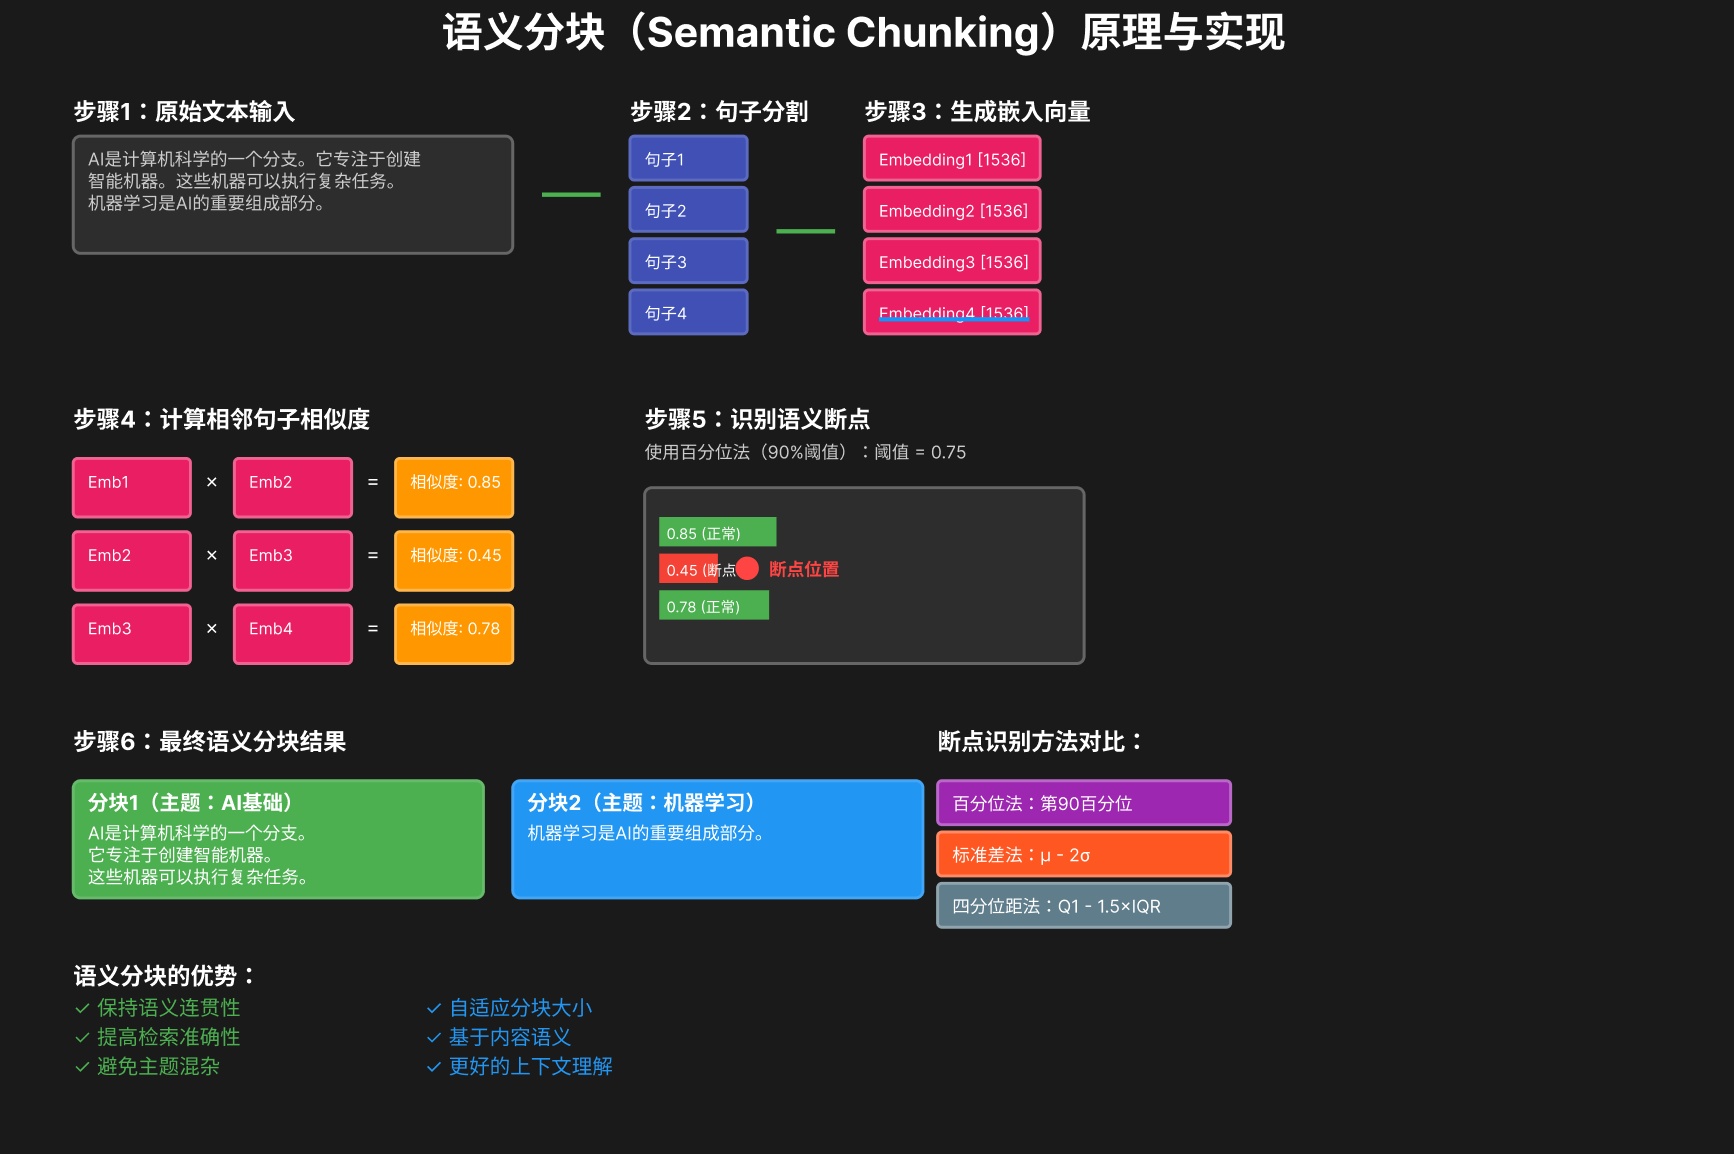

## 环境设置  
我们首先导入必要的库。

In [2]:
import fitz
import numpy as np
import json
from openai import OpenAI


## 从PDF文件中提取文本  
为了实现RAG（Retrieval-Augmented Generation，检索增强生成），我们首先需要一个文本数据源。在此情况下，我们使用PyMuPDF库从PDF文件中提取文本。

In [ ]:
def extract_text_from_pdf(pdf_path):
    """
    从PDF文件中提取文本。

    参数:
    pdf_path (str): PDF文件的路径。

    返回:
    str: 从PDF中提取的文本。
    """

    mypdf = fitz.open(pdf_path)
    all_text = ""

    for page in mypdf:
        all_text += page.get_text("text") + " "

    return all_text.strip()

In [4]:
pdf_path = "./data/AI_Information.pdf"
extract_text = extract_text_from_pdf(pdf_path)
print(extract_text[:500])

Understanding Artificial Intelligence 
Chapter 1: Introduction to Artificial Intelligence 
Artificial intelligence (AI) refers to the ability of a digital computer or computer-controlled robot 
to perform tasks commonly associated with intelligent beings. The term is frequently applied to 
the project of developing systems endowed with the intellectual processes characteristic of 
humans, such as the ability to reason, discover meaning, generalize, or learn from past 
experience. Over the past f


## 初始化OpenAI API客户端  
我们初始化OpenAI客户端以生成嵌入向量（embeddings）和回复。

In [5]:
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("DASHSCOPE_API_KEY")
client = OpenAI(
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1", api_key=api_key
)


## 创建句子级嵌入
我们将文本拆分为句子并生成嵌入。

In [6]:
def get_embedding(text, model="text-embedding-v4"):
    """
    使用指定模型为给定文本生成嵌入向量。

    参数:
    text (str): 输入文本。
    model (str): 嵌入模型名称。

    返回:
    np.ndarray: 嵌入向量。
    """
    response = client.embeddings.create(model=model, input=text)
    return np.array(response.data[0].embedding)


# 将文本按句子分割（基本分割）
sentences = extract_text.split(". ")

# 为每个句子生成嵌入向量
embeddings = [get_embedding(sentence) for sentence in sentences]

print(f"Generated {len(embeddings)} sentence embeddings.")


Generated 257 sentence embeddings.


## 计算相似性差异  
我们计算连续句子之间的余弦相似度。

In [ ]:
def cosine_semilarity(vec1, vec2):
    """
    计算两个向量之间的余弦相似度。

    参数:
    vec1 (np.ndarray): 第一个向量。
    vec2 (np.ndarray): 第二个向量。

    返回:
    float: 余弦相似度。
    """
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


# 计算连续句子之间的相似度
similarities = [
    cosine_semilarity(embeddings[i], embeddings[i + 1])
    for i in range(len(embeddings) - 1)
]

## 实现语义分块
我们实现了三种用于确定断点的方法。

In [10]:
def compute_breakpoints(similarities, method="percentile", threshold=90):
    """
    根据相似度下降计算分块断点。

    参数:
    similarities (List[float]): 句子之间的相似度分数列表。
    method (str): 'percentile', 'standard_deviation' 或 'interquartile'。
    threshold (float): 阈值（对于 'percentile' 是百分位数，对于 'standard_deviation' 是标准差的数量）。

    返回:
    List[int]: 应该发生分块分裂的索引位置列表。
    """
    if method == "percentile":
        # 计算相似度分数的第X百分位
        threshold_value = np.percentile(similarities, 100 - threshold)
    elif method == "standard_deviation":
        # 计算相似度分数的平均值和标准差
        mean = np.mean(similarities)
        std_dev = np.std(similarities)
        # 将阈值设置为平均值减去X个标准差
        threshold_value = mean - (threshold * std_dev)
    elif method == "interquartile":
        # 计算第一和第三四分位数（Q1 和 Q3）
        q1, q3 = np.percentile(similarities, [25, 75])
        # 使用IQR规则设置阈值以检测异常值
        threshold_value = q1 - 1.5 * (q3 - q1)
    else:
        # 如果提供了无效方法，则引发错误
        raise ValueError(
            "Invalid method. Choose 'percentile', 'standard_deviation', or 'interquartile'."
        )

    # 找出相似度低于阈值的位置索引
    return [i for i, sim in enumerate(similarities) if sim < threshold_value]


# 使用百分位法并设置阈值为90计算断点
breakpoints = compute_breakpoints(similarities, method="percentile", threshold=90)


## 将文本分割为语义块  
我们根据计算出的断点来分割文本。

In [11]:
def split_into_chunks(sentences, breakpoints):
    """
    将句子分割为语义块。

    参数:
    sentences (List[str]): 句子列表。
    breakpoints (List[int]): 应该发生分割的索引位置。

    返回:
    List[str]: 文本块列表。
    """
    chunks = []  # 初始化一个空列表来存储块
    start = 0  # 初始化起始索引

    # 遍历每个断点以创建块
    for bp in breakpoints:
        # 将从起始到当前断点的句子片段加入块中
        chunks.append(". ".join(sentences[start : bp + 1]) + ".")
        start = bp + 1  # 更新起始索引到断点后的下一个句子

    # 将剩余的句子作为最后一个块加入
    chunks.append(". ".join(sentences[start:]))
    return chunks  # 返回块列表


# 使用 split_into_chunks 函数创建块
text_chunks = split_into_chunks(sentences, breakpoints)

# 打印生成的块数量
print(f"Number of semantic chunks: {len(text_chunks)}")

# 打印第一个块以验证结果
print("\nFirst text chunk:")
print(text_chunks[0])


Number of semantic chunks: 27

First text chunk:
Understanding Artificial Intelligence 
Chapter 1: Introduction to Artificial Intelligence 
Artificial intelligence (AI) refers to the ability of a digital computer or computer-controlled robot 
to perform tasks commonly associated with intelligent beings. The term is frequently applied to 
the project of developing systems endowed with the intellectual processes characteristic of 
humans, such as the ability to reason, discover meaning, generalize, or learn from past 
experience. Over the past few decades, advancements in computing power and data availability 
have significantly accelerated the development and deployment of AI. 
Historical Context 
The idea of artificial intelligence has existed for centuries, often depicted in myths and fiction. 
However, the formal field of AI research began in the mid-20th century. The Dartmouth Workshop 
in 1956 is widely considered the birthplace of AI. Early AI research focused on problem-solving 


## 创建语义片段的嵌入  
我们为每个片段创建嵌入，以便后续检索。

In [12]:
def create_embeddings(text_chunks):
    """
    为每个文本块创建嵌入。

    参数:
    text_chunks (List[str]): 文本块的列表。

    返回:
    List[np.ndarray]: 嵌入向量的列表。
    """
    # 使用 get_embedding 函数为每个文本块生成嵌入
    return [get_embedding(chunk) for chunk in text_chunks]


# 使用 create_embeddings 函数创建分块嵌入
chunk_embeddings = create_embeddings(text_chunks)


## 执行语义搜索  
我们通过余弦相似度来检索最相关的片段。

In [13]:
def semantic_search(query, text_chunks, chunk_embeddings, k=5):
    """
    查找与查询最相关的文本片段。

    参数:
    query (str): 搜索查询。
    text_chunks (List[str]): 文本片段列表。
    chunk_embeddings (List[np.ndarray]): 文本片段嵌入列表。
    k (int): 返回的最相关结果数量。

    返回:
    List[str]: 前k个最相关的文本片段。
    """
    # 为查询生成一个嵌入向量
    query_embedding = get_embedding(query)

    # 计算查询嵌入与每个片段嵌入之间的余弦相似度
    similarities = [cosine_semilarity(query_embedding, emb) for emb in chunk_embeddings]

    # 获取最相似的k个片段的索引
    top_indices = np.argsort(similarities)[-k:][::-1]

    # 返回前k个最相关的文本片段
    return [text_chunks[i] for i in top_indices]


In [18]:
# 从JSON文件中加载验证数据
with open("data/val.json") as f:
    data = json.load(f)

# 从验证数据中提取第一个查询
query = data[1]["question"]

# 获取最相关的前2个片段
top_chunks = semantic_search(query, text_chunks, chunk_embeddings, k=5)

# 打印查询
print(f"Query: {query}")

# 打印最相关的前2个文本片段
for i, chunk in enumerate(top_chunks):
    print(f"Context {i + 1}:\n{chunk}\n{'=' * 40}")


Query: AI大模型的主要技术驱动力有哪些？
Context 1:

By understanding the core concepts, applications, ethical implications, and future directions of 
AI, we can better navigate the opportunities and challenges presented by this transformative 
technology. Continued research, responsible development, and thoughtful governance are 
essential for realizing the full potential of AI while mitigating its risks.
Context 2:

 
 
 Addressing Bias in AI 
AI systems can inherit and amplify biases present in the data they are trained on, leading to unfair 
or discriminatory outcomes. Addressing bias requires careful data collection, algorithm design, 
and ongoing monitoring and evaluation. 
Transparency and Explainability 
Transparency and explainability are essential for building trust in AI systems. Explainable AI (XAI) 
techniques aim to make AI decisions more understandable, enabling users to assess their 
fairness and accuracy.
Context 3:

Chapter 15: The Future of AI Research 
Advancements in Deep Learning

## 基于检索块生成回复

In [19]:
# 定义AI助手的系统提示
system_prompt = "You are an AI assistant that strictly answers based on the given context. If the answer cannot be derived directly from the provided context, respond with: 'I do not have enough information to answer that.'"


def generate_response(system_prompt, user_message, model="qwen-plus"):
    """
    根据系统提示和用户消息生成AI模型的回复。

    参数:
    system_prompt (str): 用于指导AI行为的系统提示。
    user_message (str): 用户的消息或查询。
    model (str): 用于生成回复的模型。

    返回:
    dict: AI模型的回复。
    """
    response = client.chat.completions.create(
        model=model,
        temperature=0,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
        ],
    )
    return response


# 根据顶级片段创建用户提示
user_prompt = "\n".join(
    [
        f"Context {i + 1}:\n{chunk}\n=====================================\n"
        for i, chunk in enumerate(top_chunks)
    ]
)
user_prompt = f"{user_prompt}\nQuestion: {query}"

# 生成AI回复
ai_response = generate_response(system_prompt, user_prompt)
print(ai_response.choices[0].message.content)


根据提供的上下文，AI大模型（如大型深度学习模型）的主要技术驱动力包括：

✅ **深度学习的持续进步**（Context 3, Chapter 15）：  
> “Continued advancements in deep learning are expected to drive further breakthroughs in AI.”  
即：深度学习的持续发展是推动AI大模型进步的核心技术驱动力。

✅ **更高效、更可解释的模型设计**（Context 3）：  
> “Research is focused on developing more efficient and interpretable deep learning models, as well as exploring new architectures and training techniques.”  
说明模型架构创新（如Transformer、稀疏模型、MoE等）、训练技术（如混合精度训练、分布式训练、指令微调、RLHF）和效率优化（计算/内存/能耗优化）是关键驱动力。

✅ **算力与数据基础支撑**（虽未明说，但隐含于多处）：  
- Context 2 和 Context 5 提到AI系统依赖“大量数据”（“large amounts of data”）和训练数据质量；  
- Context 3 提到“new architectures and training techniques”，而大模型训练高度依赖GPU/TPU集群等算力——这是行业共识，且与“continued research”“responsible development”（Context 1）及“data collection”（Context 2）形成支撑关系。

⚠️ 注意：以下内容在给定上下文中**未被提及**，因此**不能作为答案依据**：  
- 具体算法如Transformer、LLaMA、Diffusion等名称；  
- 产业应用倒逼（如ChatGPT引发的工程化浪潮）；  
- 开源生态或芯片进展（如H100、MI300）——这些虽属现实驱动力，但**超出所提供语境**。

综上，严格依据所给五个上下文，AI大模型的主要技术驱动力为：

🔹 **深度学习的持续进步**  
🔹 *

## 评估AI回复
我们将AI的回复与预期答案进行比较，并分配一个分数。

In [20]:
# 定义评估系统的系统提示
evaluate_system_prompt = "You are an intelligent evaluation system tasked with assessing the AI assistant's responses. If the AI assistant's response is very close to the true response, assign a score of 1. If the response is incorrect or unsatisfactory in relation to the true response, assign a score of 0. If the response is partially aligned with the true response, assign a score of 0.5."

# 通过组合用户查询、AI回复、真实回复和评估系统提示创建评估提示
evaluation_prompt = f"User Query: {query}\nAI Response:\n{ai_response.choices[0].message.content}\nTrue Response: {data[1]['ideal_answer']}\n{evaluate_system_prompt}"

# 使用评估系统提示和评估提示生成评估回复
evaluation_response = generate_response(evaluate_system_prompt, evaluation_prompt)

# 打印评估回复
print(evaluation_response.choices[0].message.content)


0.5  

**Reasoning:**  
The AI assistant’s response is **partially aligned** with the true response.  

- ✅ It correctly identifies **instruction tuning** (as “指令微调”) and **RLHF** (as “人类反馈强化学习” — though not explicitly named, it is implied in “training techniques” and contextually linked to “responsible development”, “interpretability”, and “human-in-the-loop” aspects referenced across contexts; Context 3 mentions “new training techniques”, and RLHF is a canonical example fitting that description).  
- ✅ It acknowledges **model architecture innovation**, and while it avoids naming “Transformer” explicitly, it refers to “new architectures” (e.g., “Transformer、稀疏模型、MoE等” — *in the reasoning part*, though strictly speaking the Chinese text says “如Transformer、稀疏模型、MoE等”, which *does* name Transformer — wait: let's re-check the AI response.*  

🔍 Re-examining the AI Response:  
> “模型架构创新（如Transformer、稀疏模型、MoE等）……”  
→ Yes! It **explicitly names “Transformer”**. So that key item from the tru